# PERSUADE/LLM Phase-1 -- Predictions distribution review

Reviews the OOF predictions emitted by PS1 (`stage_1_aes/predictions.csv`, 17,307 rows).

Three figures:
1. **Figure 1** -- distribution of the human-graded `true_score` (integer 1-6).
2. **Figure 2** -- distribution of `predicted_score` (LightGBM OOF, float):
    - 2A: histogram of the raw float values (50 bins) -- shows the actual shape.
    - 2B: rounded to integer + value_counts -- directly comparable to Figure 1.
3. **Figure 3** -- where the **top-10** essays (selected by `predicted_score`) sit on the distribution, with a table of their `true_score`.

Output figures land in `figures/` next to this notebook, 300 dpi PNG (per `feedback_figures_png_only.md`).

## Pipeline summary -- datafan07's model

The `predictions.csv` reviewed below is produced by reproducing the Kaggle notebook
`datafan07/some-extra-features-cv-0-83` locally on our workstation
(via `scripts/stage_1_run_kaggle_notebook.py`). The notebook integrates three
different model families; only the LightGBM ensemble produces the final score, the
other two extract features.

### Models used (exact names)

| Role | Model | Source / what it does |
|---|---|---|
| Feature extractor 1 | **`microsoft/deberta-v3-small`** &times; 5 fine-tuned checkpoints | Loaded from `datafan07/sent-debsmall`. Each was finetuned by datafan07 on the Feedback Prize III ELL dataset; here we only run inference and average the embeddings per essay. ~140M parameters each, GPU-friendly. |
| Feature extractor 2 | **`sklearn.linear_model.Ridge`** wrapped by **`MultiOutputRegressor`** | alpha=1.0, fitted on the DeBERTa embeddings of `feedback-data` to predict 6 sub-scores (cohesion, syntax, vocabulary, phraseology, grammar, conventions). Applied to AES 2.0 essays as 6 transfer features. |
| Final regressor | **`lightgbm.LGBMRegressor`** &times; 15-fold ensemble | objective = custom QWK gradient (a=2.998, b=1.092), learning_rate=0.01, n_estimators=10000 with early_stopping(500), extra_trees=True, class_weight=balanced, random_state=42. `StratifiedKFold(n_splits=15, shuffle=True, random_state=42)`. |

### Pipeline (cell-by-cell in the original notebook)

| # | Stage | Notebook cells | Compute | Time on RTX PRO 4000 Blackwell |
|---:|---|---|---|---|
| 1 | Setup imports + load `train.csv` | 2-3 | CPU | < 1s |
| 2 | **Textstat features** (readability, complexity, grade-level) | 4-5 | CPU | 1-2 min |
| 3 | **Linguistic features** via spaCy (NER + POS + TAG counts and ratios) | 6-9 | CPU, single-thread | ~15 min |
| 4 | **Spell-check** error counts via `pyspellchecker` | 10-12 | CPU | 2-5 min |
| 5 | Load 5 DeBERTa-small folds, inference &rarr; embeddings, fit Ridge on feedback-data, predict 6 sub-scores for AES essays | 13-17 | **GPU** | 7-10 min |
| 6 | Concatenate all features &rarr; train LightGBM **15-fold CV** with custom QWK objective | 20 | CPU | 2-5 min |
| 7 | Post-process (mean across folds + clip + round) + write `submission.csv` | 21-25 | CPU | < 1s |

Our wrapper patched the `/kaggle/input/...` paths so the same pipeline runs locally,
and injected one extra cell to export the out-of-fold (OOF) predictions for PS2-PS5.
End-to-end reproduction time on our workstation: **~28 min**, yielding
**QWK = 0.8352** (vs datafan07's published **0.83**).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve paths relative to this notebook's location
NOTEBOOK_DIR = Path.cwd()
PREDICTIONS_PATH = (NOTEBOOK_DIR / '..' / 'runs' / 'run_001_seed_42' / 'stage_1_aes' / 'predictions.csv').resolve()
FIGURES_DIR = (NOTEBOOK_DIR / 'figures').resolve()
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PREDICTIONS_PATH)
print(f'Loaded: {PREDICTIONS_PATH}')
print(f'Shape:  {df.shape}')
print(f'Cols:   {list(df.columns)}')
print()
print('Dtypes:')
print(df.dtypes)
print()
print(f'true_score      range:  [{df["true_score"].min()}, {df["true_score"].max()}]  (int)')
print(f'predicted_score range:  [{df["predicted_score"].min():.4f}, {df["predicted_score"].max():.4f}]  (float)')
df.head(3)

Loaded: C:\Users\razel\OneDrive - Ariel University\Desktop\Ariel\data-analytics\Thesis\project_c\experiments\persuade_aes\runs\run_001_seed_42\stage_1_aes\predictions.csv
Shape:  (17307, 4)
Cols:   ['essay_id', 'essay_text', 'predicted_score', 'true_score']

Dtypes:
essay_id            object
essay_text          object
predicted_score    float64
true_score           int64
dtype: object

true_score      range:  [1, 6]  (int)
predicted_score range:  [0.6288, 6.3376]  (float)


,essay_id,essay_text,predicted_score,true_score
0,000d118,Many people have car where they live. The thin...,1.734814,3
1,000fe60,I am a scientist at NASA that is discussing th...,2.864706,3
2,001ab80,People always wish they had the same technolog...,4.617423,4


## Figure 1 -- True score distribution

Human-graded score per essay, integer 1-6. The PERSUADE 2.0 train set is what the original Kaggle competition used; the distribution is centered on 3-4 (typical Likert scale).

In [ ]:
# Lihi's formal-report convention: no in-figure title.
# Flip WITH_TITLE to True for informal use; the file is then saved as
# `fig1_..._titled.png` so the formal version is never overwritten.
WITH_TITLE = False

true_counts = df['true_score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(true_counts.index, true_counts.values, edgecolor='black', color='steelblue')
ax.set_xlabel('Score')
ax.set_ylabel('Number of essays')
if WITH_TITLE:
    ax.set_title(f'Figure 1 -- True score distribution (PERSUADE 2.0 train, n={len(df):,})')
ax.set_xticks(true_counts.index)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig1_name = 'fig1_true_score_distribution'
plt.savefig(FIGURES_DIR / (f'{fig1_name}_titled.png' if WITH_TITLE else f'{fig1_name}.png'), dpi=300)
plt.show()

print('Counts:')
print(true_counts.to_string())

## Figure 2 -- Predicted score distribution

The model's OOF predictions are float (LightGBM regression output + constant offset, ~[1, 6] range). Two views:
- **2A**: raw float histogram, 50 bins -- shows where the model concentrates its predictions.
- **2B**: rounded to integer + clipped to [1, 6] + value_counts -- direct comparison to Figure 1.

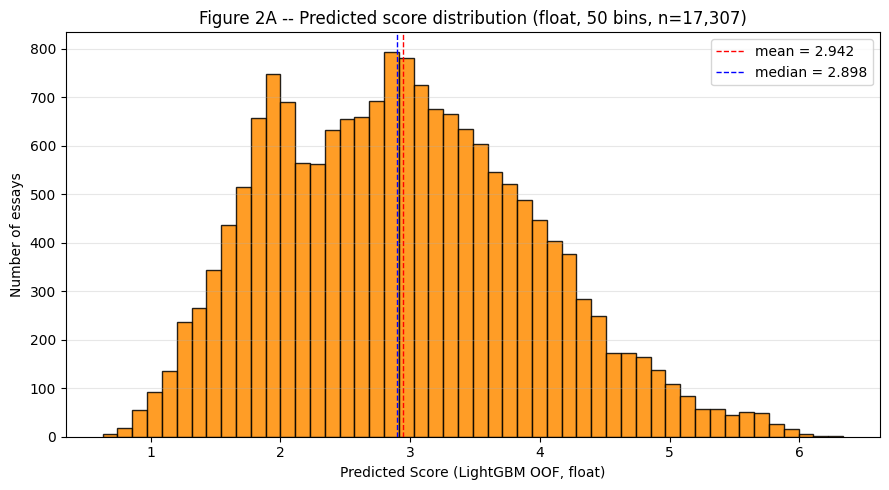

predicted_score statistics:
count    17307.000000
mean         2.942412
std          0.998310
min          0.628753
25%          2.135445
50%          2.897549
75%          3.626563
max          6.337623


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['predicted_score'], bins=50, edgecolor='black', color='darkorange', alpha=0.85)
ax.set_xlabel('Predicted Score (LightGBM OOF, float)')
ax.set_ylabel('Number of essays')
ax.set_title(f'Figure 2A -- Predicted score distribution (float, 50 bins, n={len(df):,})')
ax.grid(axis='y', alpha=0.3)
ax.axvline(df['predicted_score'].mean(), color='red', linestyle='--', linewidth=1, label=f'mean = {df["predicted_score"].mean():.3f}')
ax.axvline(df['predicted_score'].median(), color='blue', linestyle='--', linewidth=1, label=f'median = {df["predicted_score"].median():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2a_predicted_score_float.png', dpi=300)
plt.show()

print(f'predicted_score statistics:')
print(df['predicted_score'].describe().to_string())

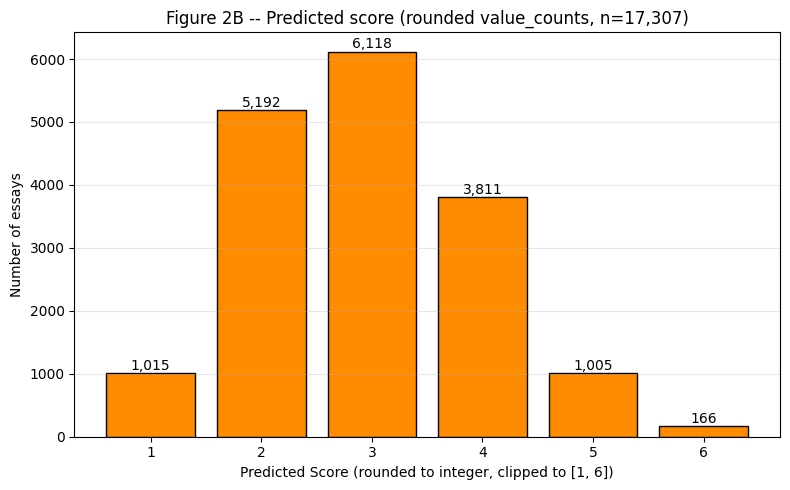

Rounded prediction counts (vs true score counts for comparison):
   true_score (Fig 1)  predicted (Fig 2B)  diff (pred - true)
1                1252                1015                -237
2                4723                5192                 469
3                6280                6118                -162
4                3926                3811                -115
5                 970                1005                  35
6                 156                 166                  10


In [4]:
# Round + clip + value_counts (direct comparison to Figure 1)
df['pred_rounded'] = df['predicted_score'].round().clip(1, 6).astype(int)
pred_counts = df['pred_rounded'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pred_counts.index, pred_counts.values, edgecolor='black', color='darkorange')
for x, v in zip(pred_counts.index, pred_counts.values):
    ax.text(x, v + 50, f'{v:,}', ha='center', fontsize=10)
ax.set_xlabel('Predicted Score (rounded to integer, clipped to [1, 6])')
ax.set_ylabel('Number of essays')
ax.set_title(f'Figure 2B -- Predicted score (rounded value_counts, n={len(df):,})')
ax.set_xticks(range(1, 7))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2b_predicted_score_rounded.png', dpi=300)
plt.show()

print('Rounded prediction counts (vs true score counts for comparison):')
comparison = pd.DataFrame({
    'true_score (Fig 1)': true_counts.reindex(range(1, 7), fill_value=0),
    'predicted (Fig 2B)': pred_counts.reindex(range(1, 7), fill_value=0),
})
comparison['diff (pred - true)'] = comparison['predicted (Fig 2B)'] - comparison['true_score (Fig 1)']
print(comparison.to_string())

## Figure 3 -- Top-10 essays

What the LLM pairwise refinement (PS3) will receive. Sorted by `predicted_score` descending; their `true_score` shows whether the model's top picks were genuinely the strongest essays per the human grader.

In [5]:
top_10 = df.sort_values('predicted_score', ascending=False).head(10).reset_index(drop=True)
top_10.insert(0, 'rank', range(1, 11))

print('Top-10 essays (by predicted_score, desc):')
print(top_10[['rank', 'essay_id', 'predicted_score', 'true_score']].to_string(index=False))
print()
print(f'True scores of top-10:                  {sorted(top_10["true_score"].tolist(), reverse=True)}')
print(f'Mean true_score of top-10:              {top_10["true_score"].mean():.2f}')
print(f'How many of top-10 have true_score=6?   {(top_10["true_score"] == 6).sum()} (of 10)')
print(f'How many have true_score >= 5?          {(top_10["true_score"] >= 5).sum()} (of 10)')

Top-10 essays (by predicted_score, desc):
 rank essay_id  predicted_score  true_score
    1  6e990ee         6.337623           6
    2  d8361b9         6.269568           6
    3  dda8663         6.150910           6
    4  14174ed         6.115952           6
    5  e046c43         6.085538           6
    6  80b646c         6.033545           6
    7  980a15b         6.030457           6
    8  597f576         6.021579           6
    9  4d00492         6.003071           6
   10  8230435         5.988447           6

True scores of top-10:                  [6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
Mean true_score of top-10:              6.00
How many of top-10 have true_score=6?   10 (of 10)
How many have true_score >= 5?          10 (of 10)


## Reproduction check vs datafan07 published CV

datafan07 published a QWK (Quadratic Weighted Kappa) score of **0.83** in the notebook title. 
Compute the same metric on our OOF predictions to confirm we reproduced the result locally.

QWK on PERSUADE 2.0 uses ordinal labels (1-6). To compute it on float predictions we round + clip to [1, 6].

In [7]:
from sklearn.metrics import cohen_kappa_score

y_pred_int = df['predicted_score'].round().clip(1, 6).astype(int)
y_true = df['true_score']

our_qwk = cohen_kappa_score(y_true, y_pred_int, weights='quadratic')
datafan07_published = 0.83

print(f'Our reproduction QWK:    {our_qwk:.4f}')
print(f'datafan07 published CV:  {datafan07_published:.4f}')
print(f'Difference:              {(our_qwk - datafan07_published):+.4f}')
print()
print('Confusion matrix (true rows x predicted cols):')
cm = pd.crosstab(y_true, y_pred_int, rownames=['true'], colnames=['pred'], margins=True)
print(cm.to_string())

Our reproduction QWK:    0.8352
datafan07 published CV:  0.8300
Difference:              +0.0052

Confusion matrix (true rows x predicted cols):
pred     1     2     3     4     5    6    All
true                                          
1      635   563    50     4     0    0   1252
2      370  3450   866    37     0    0   4723
3        9  1159  4241   858    13    0   6280
4        1    20   951  2617   329    8   3926
5        0     0    10   293   596   71    970
6        0     0     0     2    67   87    156
All   1015  5192  6118  3811  1005  166  17307


## Top-50 view with top-10 highlighted

A wider lens than top-10. We expect mostly true_score=6 essays at the very top, but as we go down to rank 11-50 we should 
start seeing some true_score=5 and even true_score=4 essays. This matters for the LLM pairwise stage (PS3) -- the more 
variance in true_score among the selected essays, the more pairs we can actually evaluate at PS5.

The first 10 rows (rank 1-10) are highlighted in yellow -- these are the same essays Figure 3 marks with red lines.

In [ ]:
top_50 = df.sort_values('predicted_score', ascending=False).head(50).reset_index(drop=True)
top_50.insert(0, 'rank', range(1, 51))
top_50['in_top_10'] = top_50['rank'] <= 10

# Distribution summary
print('Distribution of true_score in top-50:')
print(top_50['true_score'].value_counts().sort_index().to_string())
print()
print(f'Mean true_score in top-50: {top_50["true_score"].mean():.2f}')
print(f'# true=6 in top-10: {((top_50["rank"] <= 10) & (top_50["true_score"] == 6)).sum()} / 10')
print(f'# true=6 in top-50: {(top_50["true_score"] == 6).sum()} / 50')
print()

# DataFrame with yellow highlight on top-10 rows
view = top_50[['rank', 'essay_id', 'predicted_score', 'true_score', 'in_top_10']].copy()
view['predicted_score'] = view['predicted_score'].round(4)

def highlight_top10(row):
    top_50 = df.sort_values('predicted_score', ascending=False).head(50).reset_index(drop=True)
    top_50.insert(0, 'rank', range(1, 51))
    top_50['in_top_10'] = top_50['rank'] <= 10

    # Distribution summary
    print('Distribution of true_score in top-50:')
    print(top_50['true_score'].value_counts().sort_index().to_string())
    print()
    print(f'Mean true_score in top-50: {top_50["true_score"].mean():.2f}')
    print(f'# true=6 in top-10: {((top_50["rank"] <= 10) & (top_50["true_score"] == 6)).sum()} / 10')
    print(f'# true=6 in top-50: {(top_50["true_score"] == 6).sum()} / 50')
    print()

    # DataFrame with light blue highlight on top-10 rows
    view = top_50[['rank', 'essay_id', 'predicted_score', 'true_score', 'in_top_10']].copy()
    view['predicted_score'] = view['predicted_score'].round(4)

    def highlight_top10(row):
        return ['background-color: #add8e6; font-weight: bold' if row['in_top_10'] else '' for _ in row]

    view.style.apply(highlight_top10, axis=1).hide(axis='index')

view.style.apply(highlight_top10, axis=1).hide(axis='index')

Distribution of true_score in top-50:
true_score
4     2
5    16
6    32

Mean true_score in top-50: 5.60
# true=6 in top-10: 10 / 10
# true=6 in top-50: 32 / 50



rank,essay_id,predicted_score,true_score,in_top_10
1,6e990ee,6.337600,6,True
2,d8361b9,6.269600,6,True
3,dda8663,6.150900,6,True
4,14174ed,6.116000,6,True
5,e046c43,6.085500,6,True
6,80b646c,6.033500,6,True
7,980a15b,6.030500,6,True
8,597f576,6.021600,6,True
9,4d00492,6.003100,6,True
10,8230435,5.988400,6,True


## End-to-end Phase-1 results -- AES vs LLM/Copeland

After PS3 (LLM pairwise judgments on the rank 11-20 window) and PS4
(Copeland fusion of the 10x10 win matrix), we compare two rankings of
the same 10 essays against the true human scores:

- **AES ranking**: the order PS2 fed in (by `predicted_score` desc).
- **Copeland ranking**: the order derived from the 45 LLM A/B votes.

Metrics computed in `scripts/stage_5_evaluate.py` against `true_score`:

- Kendall's tau-b (tie-adjusted; the headline metric, per Lihi 2026-05-06).
- Spearman's rho.
- Pairwise accuracy (fraction of essay pairs with non-equal true scores
  whose predicted order matches the true order).

The table below loads `metrics.csv` and shows the delta from AES to
Copeland. A positive delta means the LLM-driven ranking is closer to
the human ranking than the AES ranking it replaced.


In [ ]:
import pandas as pd
from pathlib import Path

run_dir = Path('..') / 'runs' / 'run_001_seed_42'
metrics = pd.read_csv(run_dir / 'stage_5_eval' / 'metrics.csv')

pivot = metrics.pivot(index='metric', columns='method', values='value')
pivot = pivot[['aes', 'copeland']]
pivot['delta'] = pivot['copeland'] - pivot['aes']
pivot = pivot.loc[['tau_b', 'spearman_rho', 'pairwise_accuracy']]
pivot.columns = ['AES (Stage 1)', 'Copeland / LLM (Stage 4)', 'Delta']
pivot.round(4)


### Figure 4 -- Rank ladder (AES vs Copeland vs True)

Slopegraph of the 10 essays as they move across three ladders:
left = AES rank, middle = Copeland rank, right = a banded true-score
rank (since human scores are integer 1-6, multiple essays share a
score; the band is drawn at the centroid of each score level so the
slope is readable).

Lines are coloured by `true_score`. Two essays worth tracking:

- Essay `4a779d5` (true score 4): AES rank 4 -> Copeland rank 8.
  The LLM correctly demoted a weaker essay that the AES model
  over-rated.
- Essay `833118e` (true score 6): AES rank 9 -> Copeland rank 3.
  The LLM correctly promoted a strong essay that the AES model
  under-rated.


In [ ]:
# Lihi's formal-report convention: no in-figure title. Flip WITH_TITLE
# to True for informal use (slides etc.); the file is then saved as
# `fig4_..._titled.png` so the formal version is never overwritten.
WITH_TITLE = False

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path('..') / 'runs' / 'run_001_seed_42'
top_k = pd.read_csv(run_dir / 'stage_2_top_k' / 'top_k.csv')
ranking_copeland = pd.read_csv(run_dir / 'stage_4_fusion' / 'ranking_copeland.csv')

aes_rank = {row.essay_id: i + 1 for i, row in enumerate(top_k.itertuples(index=False))}
copeland_rank = {row.essay_id: int(row.rank_position) for row in ranking_copeland.itertuples(index=False)}

eids = list(aes_rank.keys())
df_plot = pd.DataFrame({
    'essay_id': eids,
    'true_score': [int(top_k.loc[top_k['essay_id'] == e, 'true_score'].iloc[0]) for e in eids],
    'aes_rank': [aes_rank[e] for e in eids],
    'copeland_rank': [copeland_rank[e] for e in eids],
})

# Banded true-rank: essays with the same true_score share a centroid
# rank on the right column so the slope is readable.
score_to_band = {}
for score in sorted(df_plot['true_score'].unique(), reverse=True):
    members = df_plot[df_plot['true_score'] == score].sort_values('copeland_rank')
    n = len(members)
    if n == 0:
        continue
    start = len(score_to_band)
    for offset, eid in enumerate(members['essay_id']):
        score_to_band[eid] = start + offset + 1
df_plot['true_rank_banded'] = df_plot['essay_id'].map(score_to_band)

color_map = {6: '#2ca02c', 5: '#bcbd22', 4: '#d62728'}

fig, ax = plt.subplots(figsize=(10, 7))
xs = [1, 2, 3]
for _, row in df_plot.iterrows():
    ys = [row['aes_rank'], row['copeland_rank'], row['true_rank_banded']]
    color = color_map.get(int(row['true_score']), '#7f7f7f')
    ax.plot(xs, ys, marker='o', color=color, linewidth=1.6, alpha=0.85)
    ax.annotate(row['essay_id'][:7], (xs[0] - 0.05, ys[0]), ha='right', va='center', fontsize=9, color=color)
    ax.annotate(f't={int(row["true_score"])}', (xs[2] + 0.05, ys[2]), ha='left', va='center', fontsize=9, color=color)

ax.set_xticks(xs)
ax.set_xticklabels(['AES rank\n(by predicted_score)', 'Copeland rank\n(by LLM wins)', 'True rank\n(by true_score, banded)'])
ax.set_ylabel('Rank within bucket (1 = best, 10 = worst)')
ax.invert_yaxis()
if WITH_TITLE:
    ax.set_title('Figure 4 -- Rank ladder: AES vs LLM/Copeland vs True (PERSUADE ranks 11-20)')
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(0.6, 3.4)

# Legend below the x-axis labels, horizontal, no frame -- keeps the
# bottom-right corner clear so the rank-10 essay's data points aren't
# hidden behind it.
counts_per_score = df_plot['true_score'].value_counts().to_dict()
handles = [
    plt.Line2D(
        [0], [0], color=color_map[s], marker='o', linewidth=2,
        label=f'true_score = {s} (n={counts_per_score.get(s, 0)})'
    )
    for s in [6, 5, 4]
]
ax.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)

fig.tight_layout()
fig4_name = 'fig4_rank_ladder_aes_llm_true'
fig.savefig(f'figures/{fig4_name}_titled.png' if WITH_TITLE else f'figures/{fig4_name}.png',
            dpi=300, bbox_inches='tight')
plt.show()
